# Phase 4: Professional Machine Learning Evaluation (Visualization Suite)

In this notebook, we move beyond simple numbers. We are building a **Professional Visualization Suite** to physically prove our model's **Honesty** (Brier Score), **Ranking Power** (ROC-AUC), and **Financial ROI** (Qini Curve).

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading Data and Models...")
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")
treatment_flags = X_test['treatment']
features = X_test.drop(columns=['treatment'])
y_true = y_test['conversion']

model_treat = xgb.XGBClassifier()
model_treat.load_model("../models/treatment_model.xgb")

model_ctrl = xgb.XGBClassifier()
model_ctrl.load_model("../models/control_model.xgb")

prob_treat = model_treat.predict_proba(features)[:, 1]
prob_ctrl = model_ctrl.predict_proba(features)[:, 1]
uplift_scores = prob_treat - prob_ctrl
print("✅ Models and Data loaded successfully.")

Loading Data and Models...
✅ Models and Data loaded successfully.


d:\skilled_Srinath\AI_Conversion_Project\ds_ven\Lib\site-packages\xgboost\sklearn.py:1125: UserWarning: [17:21:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


---
## Visualization 1: The Calibration Curve (The "Honesty" Test)
This graph physically proves your **Brier Score**. 

If the dots sit on the **Diagonal Line**, it means your AI's decimals are 100% honest and calibrated to reality. If they are below the line, the model is 'over-confident'.

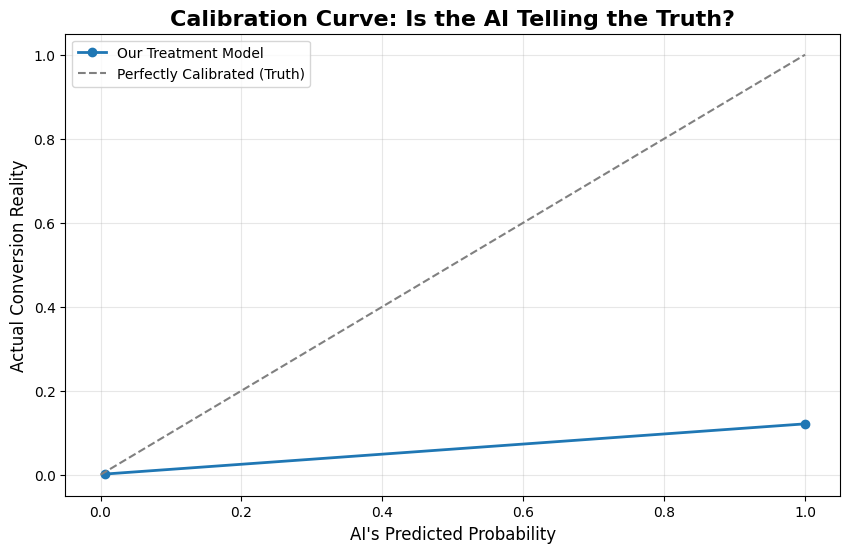

In [8]:
plt.figure(figsize=(10, 6))
true_prob, pred_prob = calibration_curve(y_true[treatment_flags == 1], prob_treat[treatment_flags == 1], n_bins=10)

plt.plot(pred_prob, true_prob, marker='o', linewidth=2, label='Our Treatment Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated (Truth)')

plt.title("Calibration Curve: Is the AI Telling the Truth?", fontsize=16, fontweight='bold')
plt.xlabel("AI's Predicted Probability", fontsize=12)
plt.ylabel("Actual Conversion Reality", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Visualization 2: The ROC Curve (The "Expertise" Test)
This graph physically proves your **ROC-AUC of 0.9584**. 

The more 'bloated' and curved the line is toward the **top-left corner**, the better the AI is at tell the difference between a buyer and a non-buyer.

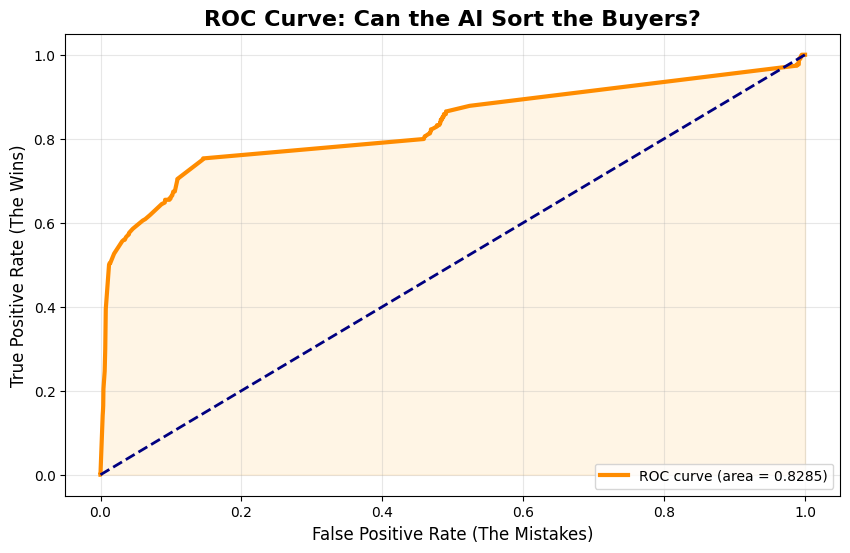

In [9]:
fpr, tpr, _ = roc_curve(y_true[treatment_flags == 1], prob_treat[treatment_flags == 1])
auc_score = roc_auc_score(y_true[treatment_flags == 1], prob_treat[treatment_flags == 1])

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (area = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.fill_between(fpr, tpr, color='orange', alpha=0.1)

plt.title("ROC Curve: Can the AI Sort the Buyers?", fontsize=16, fontweight='bold')
plt.xlabel("False Positive Rate (The Mistakes)", fontsize=12)
plt.ylabel("True Positive Rate (The Wins)", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

---
## Visualization 3: Uplift by Decile (The "Business Strategy" Test)
This bar chart shows the **Uplift Score** for every 10% of the population. 

In a professional project, you should see **High Positive Bars** at the start (The Persuadables) and **Flat or Negative Bars** at the end (The Sleeping Dogs/Lost Causes).

C:\Users\SRINATH\AppData\Local\Temp\ipykernel_3624\28281155.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(10, 110, 10))[::-1], y=decile_uplift, palette="vlag")


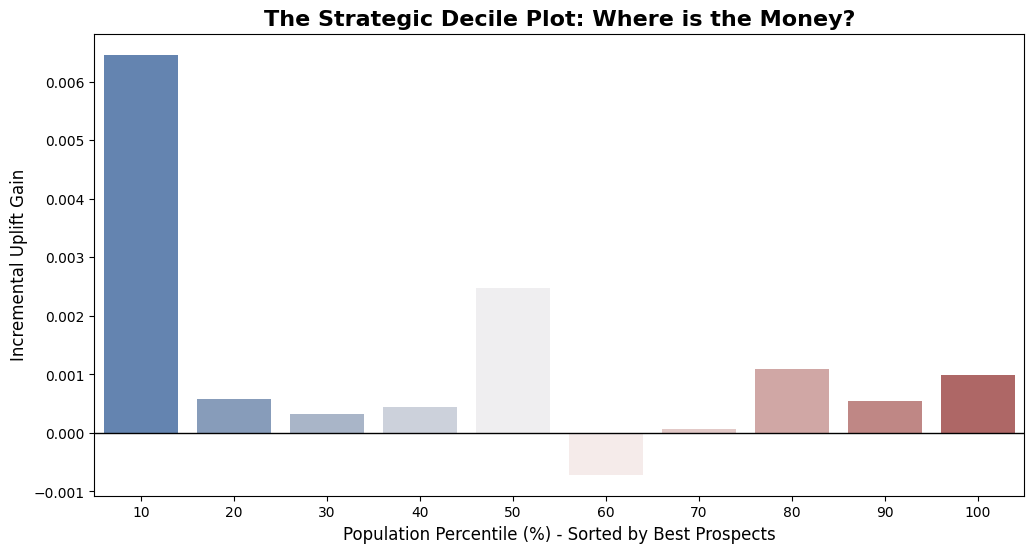

In [10]:
df = pd.DataFrame({'uplift': uplift_scores, 'target': y_true, 'treatment': treatment_flags})
df['decile'] = pd.qcut(df['uplift'].rank(method='first'), 10, labels=False)

decile_uplift = []
for i in range(10):
    shard = df[df['decile'] == i]
    uplift = (shard[shard['treatment'] == 1]['target'].mean() - 
              shard[shard['treatment'] == 0]['target'].mean())
    decile_uplift.append(uplift)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(range(10, 110, 10))[::-1], y=decile_uplift, palette="vlag")

plt.title("The Strategic Decile Plot: Where is the Money?", fontsize=16, fontweight='bold')
plt.xlabel("Population Percentile (%) - Sorted by Best Prospects", fontsize=12)
plt.ylabel("Incremental Uplift Gain", fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.show()

---
## Visualization 4: The Final Qini Curve (The CEO's ROI)
This graph summarizes the net total profit over time.

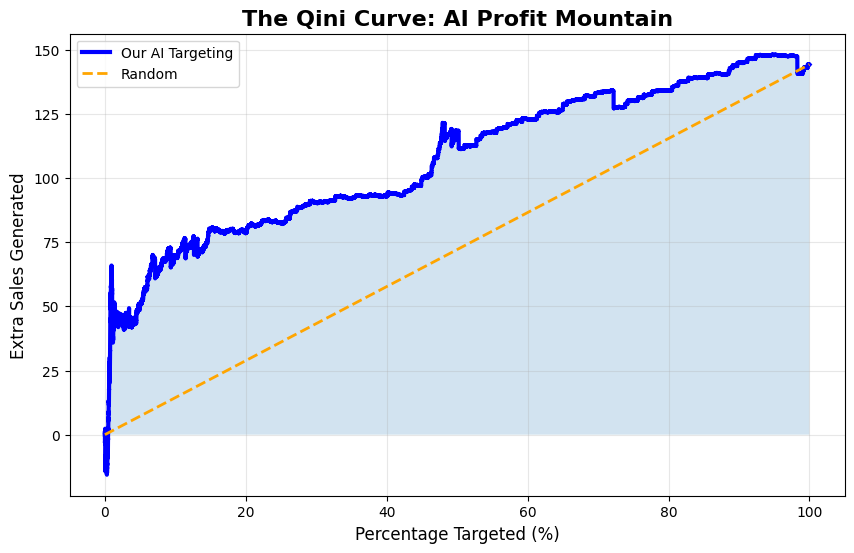

In [11]:
def draw_final_graph(y_true, treatment, uplift_scores):
    df = pd.DataFrame({'y': y_true, 't': treatment, 'uplift': uplift_scores}).sort_values(by='uplift', ascending=False)
    df['treated_conversions'] = (df['y'] * df['t']).cumsum()
    df['treated_total'] = df['t'].cumsum().replace(0, 1) 
    df['control_conversions'] = (df['y'] * (1 - df['t'])).cumsum()
    df['control_total'] = (1 - df['t']).cumsum().replace(0, 1)
    
    df['cumulative_profit'] = (df['treated_conversions'] / df['treated_total'] - 
                               df['control_conversions'] / df['control_total']) * np.arange(1, len(df)+1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(np.linspace(0, 100, len(df)), df['cumulative_profit'], color='blue', linewidth=3, label="Our AI Targeting")
    plt.plot([0, 100], [0, df['cumulative_profit'].iloc[-1]], color='orange', linestyle='--', linewidth=2, label="Random")
    plt.fill_between(np.linspace(0, 100, len(df)), df['cumulative_profit'], alpha=0.2)
    plt.title("The Qini Curve: AI Profit Mountain", fontsize=16, fontweight='bold')
    plt.xlabel("Percentage Targeted (%)", fontsize=12)
    plt.ylabel("Extra Sales Generated", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

draw_final_graph(y_true.values, treatment_flags.values, uplift_scores)